In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("/Users/TrendingPc/Documents/project/data/processed_data_last_3.csv")
df["date"] = pd.to_datetime(df["date"])

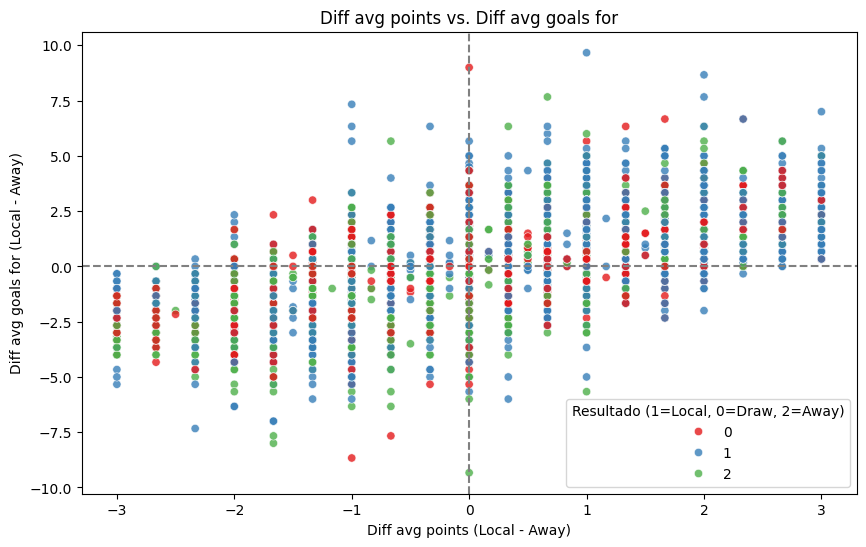

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="diff_avg_points",
    y="diff_avg_goals_for",
    hue="result",
    palette="Set1",
    alpha=0.8,
)

plt.title("Diff avg points vs. Diff avg goals for")
plt.xlabel("Diff avg points (Local - Away)")
plt.ylabel("Diff avg goals for (Local - Away)")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.legend(title="Result (1=Local, 0=Draw, 2=Away)")
plt.show()

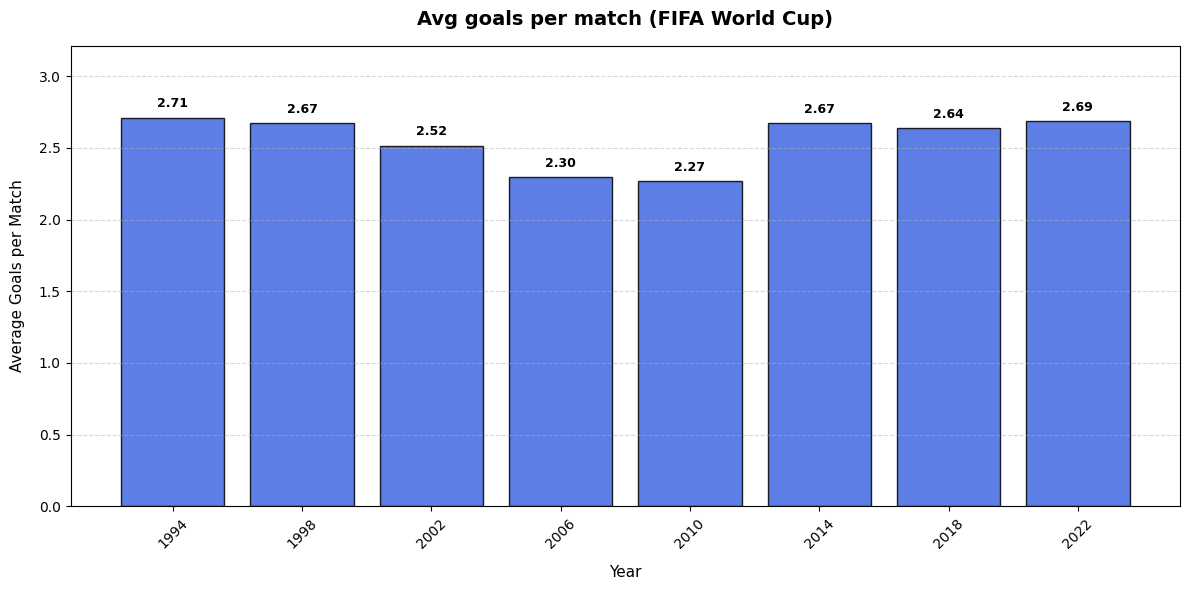

In [11]:
df["total_goals"] = df["home_score"] + df["away_score"]


df_world_cups = df[df["tournament"] == "FIFAWorldCup"].copy()
df_world_cups["year"] = df_world_cups["date"].dt.year


avg_goals = df_world_cups.groupby("year")["total_goals"].mean().reset_index()
media_goles_mundial = avg_goals.sort_values("year")

plt.figure(figsize=(12, 6))

barras = plt.bar(
    media_goles_mundial["year"].astype(str),
    media_goles_mundial["total_goals"],
    color="royalblue",
    edgecolor="black",
    alpha=0.85,
)

# Pintar los valores sobre las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2.0,
        yval + 0.05,
        f"{yval:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.title(
    "Avg goals per match (FIFA World Cup)", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Average Goals per Match", fontsize=11, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, media_goles_mundial["total_goals"].max() + 0.5)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

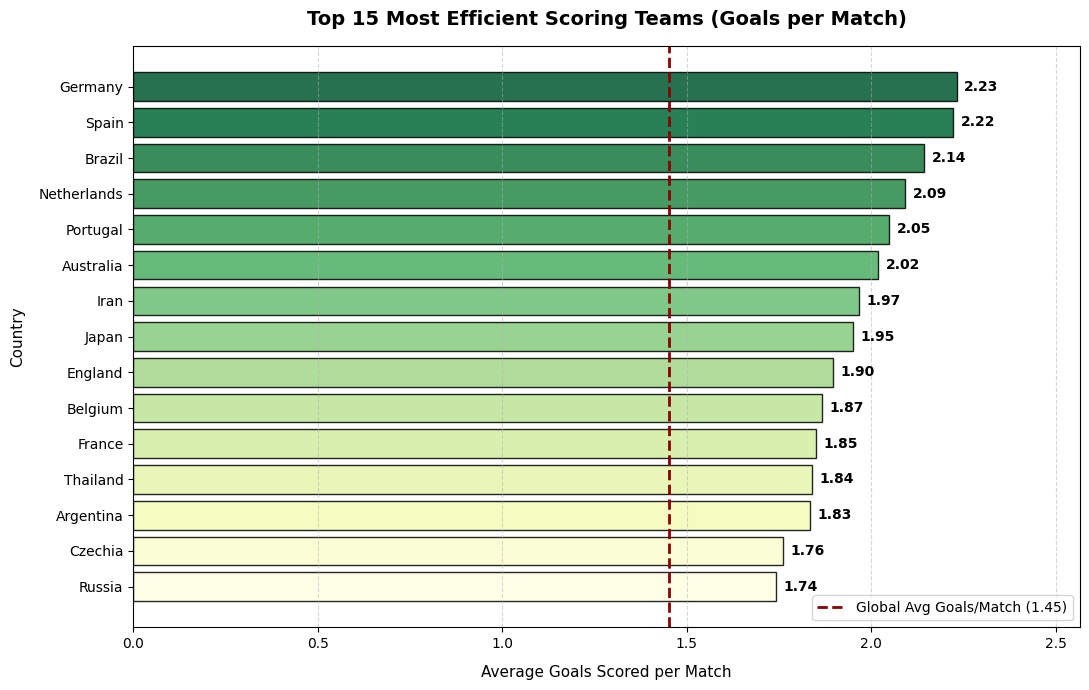

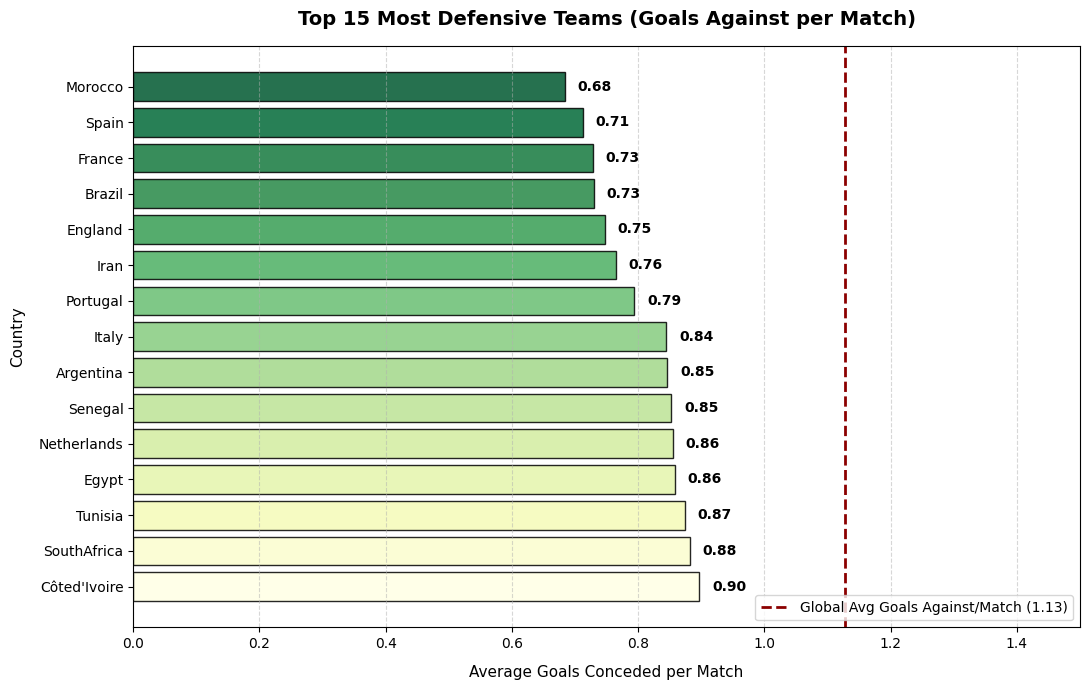

In [13]:
local_goals = df.groupby('home_team').agg(
    goals_for=('home_score', 'sum'),
    goals_against=('away_score', 'sum')
).reset_index().rename(columns={'home_team': 'team'})


away_goals = df.groupby('away_team').agg(
    goals_for=('away_score', 'sum'),
    goals_against=('home_score', 'sum')
).reset_index().rename(columns={'away_team': 'team'})

df_total_goals = pd.concat([local_goals, away_goals]).groupby('team').sum().reset_index()

local_matches = df['home_team'].value_counts().reset_index().rename(columns={'home_team': 'team', 'count': 'local_matches'})
away_matches = df['away_team'].value_counts().reset_index().rename(columns={'away_team': 'team', 'count': 'away_matches'})
df_partidos = pd.merge(local_matches, away_matches, on='team', how='outer').fillna(0)
df_partidos['total_matches'] = df_partidos['local_matches'] + df_partidos['away_matches']

df_partidos = df_partidos[df_partidos['total_matches'] > 300]

df_efficiency = pd.merge(df_total_goals, df_partidos[['team', 'total_matches']], on='team', how='inner')


df_efficiency['goals_per_match'] = df_efficiency['goals_for'] / df_efficiency['total_matches']

df_efficiency['goals_against_per_match'] = df_efficiency['goals_against'] / df_efficiency['total_matches']


avg_goals_per_match = df_efficiency['goals_per_match'].mean()
avg_goals_against_per_match = df_efficiency['goals_against_per_match'].mean()



top_eficientes = df_efficiency.sort_values(by='goals_per_match', ascending=True).tail(15)

top_defensivos = df_efficiency.sort_values(by='goals_against_per_match', ascending=False).tail(15)

plt.figure(figsize=(11, 7))
colors_efficiency = plt.cm.YlGn(pd.Series(range(len(top_eficientes))) / len(top_eficientes))

bars= plt.barh(
    top_eficientes['team'], 
    top_eficientes['goals_per_match'], 
    color=colors_efficiency, 
    edgecolor='black',
    alpha=0.85
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02, 
        bar.get_y() + bar.get_height()/2.0, 
        f'{width:.2f}', 
        ha='left', va='center', fontsize=10, fontweight='bold'
    )


plt.axvline(avg_goals_per_match, color='darkred', linestyle='--', linewidth=2, label=f'Global Avg Goals/Match ({avg_goals_per_match:.2f})')
plt.legend(loc='lower right', fontsize=10)

plt.title('Top 15 Most Efficient Scoring Teams (Goals per Match)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Goals Scored per Match', fontsize=11, labelpad=10)
plt.ylabel('Country', fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, top_eficientes['goals_per_match'].max() * 1.15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
colors_defensive = plt.cm.YlGn(pd.Series(range(len(top_defensivos))) / len(top_defensivos))

bars= plt.barh(
    top_defensivos['team'], 
    top_defensivos['goals_against_per_match'], 
    color=colors_defensive, 
    edgecolor='black',
    alpha=0.85
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02, 
        bar.get_y() + bar.get_height()/2.0, 
        f'{width:.2f}', 
        ha='left', va='center', fontsize=10, fontweight='bold'
    )


plt.axvline(avg_goals_against_per_match, color='darkred', linestyle='--', linewidth=2, label=f'Global Avg Goals Against/Match ({avg_goals_against_per_match:.2f})')
plt.legend(loc='lower right', fontsize=10)

plt.title('Top 15 Most Defensive Teams (Goals Against per Match)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Goals Conceded per Match', fontsize=11, labelpad=10)
plt.ylabel('Country', fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0,1.5)
plt.tight_layout()
plt.show()

